# Business Statement & Understanding
---

Name : Marsello Ormanda

Linkedin : [Linkedin Profile](https://www.linkedin.com/in/marsello-ormanda/)

Github : [Github Profile](https://github.com/marsello-or)

Lazada is one of the most largest e-commerce platforms in Southeast Asia, backed by Alibaba Group, with ~160 million monthly active users and 1 million active sellers across six markets (Indonesia, Malaysia, Singapore, Thailand, Vietnam, and Phillipines). As a data analyst, my goal is to help Lazada optimize revenue and reduce operational osts by analyzing publicly available product ata to uncover actionable business insights.

## Business Question & Problems
---

1. Which categoris and products generate the highest GMV (Gross Merchandise Value), and how should Lazada allocate its inventory and marketin resources to maximize revenue?
2. How effective are discounts in driving sales, and what is the optimal discount range for each product category to maximize sales without sacrificing profit margins?
3. How do LazMall and Super Seller programs impact seller performance (GMV, sales volume, and ratings), and is the platforms's invesment in these programs justified?
4. What factors (rating, reviews, price, seller reputation, promotions) most significantly influence product sales, and what shoul be lazada;s prirority for improvement?
5. Can we build a machine learning model to predict products sales volume (number_sold) based on product attributes, and use it for inventory planning?
6. How can we classify products into meaningful segments (e.g., high-potential, underperforming, premium) and use these segments to design targeted marketing and pricing strategies?

# Library Download and Installation
---

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, classification_report, silhouette_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
import xgboost as xgb
import lightgbm as lgb
from sklearn.decomposition import PCA

# Utility
import warnings
warnings.filterwarnings('ignore')

# Model Saving
import joblib
import pickle

In [2]:
# Visualization Setting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('colorblind')
plt.rcParams['figure.figsize'] = (12,6)

# Getting the main data source
---

In [3]:
url = 'https://raw.githubusercontent.com/Marsello-or/Lazada__Product_Analysis/refs/heads/main/dataset/lazada-products.csv'

df = pd.read_csv(url)

# Data Understanding
---

## Data Loading


In [4]:
url = 'https://raw.githubusercontent.com/Marsello-or/Lazada__Product_Analysis/refs/heads/main/dataset/lazada-products.csv'

df = pd.read_csv(url)

## Data Quality Check

In [5]:
# Dimension Check
print(f"\n Data Dimension:")
print(f"  - Total Rows: {len(df):,}")
print(f"  - Total Columns: {len(df.columns)}")


 Data Dimension:
  - Total Rows: 1,000
  - Total Columns: 29


In [6]:
# Checking the first 5 data row
display(df.head())

,url,title,rating,reviews,initial_price,final_price,currency,image,seller_name,breadcrumb,...,color,returns_and_warranty,is_super_seller,promotions,brand,product_variation,lazmall,domain,number_sold,gmv
0,https://www.lazada.co.id/products/dioda-damper...,DIODA DAMPER DMV 1500 TV POLYTRON NEW ORIGINAL...,4.6,27,0.0,10000.0,IDR,"[""https://img.lazcdn.com/g/ff/kf/Sc92f4b3c99c0...",YUDIANA YUDI SPERPAT ELEKTRONIK,"[""Televisi & Video"",""Televisi Digital""]",...,NaN,"[""Berubah Pikiran"",""7 Hari Gratis Pengembalian...",False,[],TR,[],False,https://www.lazada.co.id,111,1110000.0
1,https://www.lazada.co.id/products/victus-lapto...,Victus Laptop Gaming HP AMD Ryzen 5 NVIDIA GeF...,0.0,0,17555000.0,16499000.0,IDR,"[""https://img.lazcdn.com/g/p/3440632c069eddd82...",HP,"[""Komputer & Laptop"",""Laptop"",""Laptop Umum""]",...,NaN,"[""Produk Original"",""Berubah Pikiran"",""30 Hari ...",True,[],HP,"[{""name"":""Varian"",""value"":""15-fb2666AX""}]",True,https://www.lazada.co.id,0,0.0
2,https://www.lazada.co.id/products/laptop-hp-15...,Laptop HP 15s-fq5148TU Core i3 UHD 4GB & 8GB R...,5.0,47,6499000.0,6099000.0,IDR,"[""https://img.lazcdn.com/g/p/23782d5f1bd37a89c...",HP,"[""Komputer & Laptop"",""Laptop"",""Laptop Umum""]",...,14s-dq5115TU,"[""Produk Original"",""Berubah Pikiran"",""30 Hari ...",True,[],HP,"[{""name"":""Warna"",""value"":""14s-dq5115TU""}]",True,https://www.lazada.co.id,91,555009000.0
3,https://www.lazada.co.id/products/printer-hp-d...,Printer HP DeskJet 2336 All in One ( Print Sca...,5.0,177,990000.0,880000.0,IDR,"[""https://img.lazcdn.com/g/p/bf68d11f46c85761a...",HP,"[""Pencetak & Monitor"",""Printer"",""Printer Ink J...",...,2336 Putih,"[""Produk Original"",""Berubah Pikiran"",""30 Hari ...",True,[],HP,"[{""name"":""Warna"",""value"":""2336 Putih""}]",True,https://www.lazada.co.id,409,359920000.0
4,https://www.lazada.co.id/products/roda-koper-r...,"RODA KOPER, RODA PENGGANTI, RODA DOUBLE WHEEL,...",5.0,2,0.0,65000.0,IDR,"[""https://img.lazcdn.com/g/p/abc4f89073ba5380c...",dewi05588,"[""Tas & Travel"",""Tas Anak"",""Koper""]",...,NaN,"[""Berubah Pikiran"",""7 Hari Gratis Pengembalian...",False,[],Tidak Ada Merk,"[{""name"":""RODA"",""value"":""AUDI""}]",False,https://www.lazada.co.id,2,130000.0


In [7]:
# Checking dataframe info dan data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   url                     1000 non-null   object 
 1   title                   1000 non-null   object 
 2   rating                  1000 non-null   float64
 3   reviews                 1000 non-null   int64  
 4   initial_price           1000 non-null   float64
 5   final_price             1000 non-null   float64
 6   currency                1000 non-null   object 
 7   image                   1000 non-null   object 
 8   seller_name             1000 non-null   object 
 9   breadcrumb              1000 non-null   object 
 10  product_specifications  1000 non-null   object 
 11  product_description     1000 non-null   object 
 12  seller_ratings          973 non-null    float64
 13  seller_ship_on_time     933 non-null    object 
 14  seller_chat_response    878 non-null    o

In [8]:
# Missing Values Detection
print(" Missing Values:")

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing' : missing,
    'Percentage (%)': missing_pct.round(2)
})

missing_cols = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

if len(missing_cols) > 0:
  print(missing_cols)
  print(f"\n Total Missing values: {df.isnull().sum().sum():,} cells")
else:
  print("There's no missing values")

 Missing Values:
                      Missing  Percentage (%)
color                     500            50.0
colors                    500            50.0
seller_chat_response      122            12.2
seller_ship_on_time        67             6.7
seller_ratings             27             2.7

 Total Missing values: 1,216 cells


In [9]:
# Duplicate Checking

print("Duplicate Checking")

duplicates = df.duplicated().sum()
print(f" Duplicate Rows Amount: {duplicates:,}")

if duplicates > 0:
  print(f" Duplicated Percentage: {(duplicates/len(df))*100:.2f}%")
else:
  print(" Theres no duplicated row")

Duplicate Checking
 Duplicate Rows Amount: 0
 Theres no duplicated row


In [10]:
# Row Unique Values

print(" Unique Values Checking")

for col in df.columns:
  unique_count = df[col].nunique()
  print(f" {col:25} | {unique_count:,} unique values")

 Unique Values Checking
 url                       | 1,000 unique values
 title                     | 402 unique values
 rating                    | 12 unique values
 reviews                   | 143 unique values
 initial_price             | 291 unique values
 final_price               | 516 unique values
 currency                  | 5 unique values
 image                     | 404 unique values
 seller_name               | 197 unique values
 breadcrumb                | 80 unique values
 product_specifications    | 404 unique values
 product_description       | 397 unique values
 seller_ratings            | 16 unique values
 seller_ship_on_time       | 29 unique values
 seller_chat_response      | 19 unique values
 sku                       | 1,000 unique values
 mpn                       | 404 unique values
 colors                    | 153 unique values
 variations                | 300 unique values
 color                     | 229 unique values
 returns_and_warranty      | 44 unique 

In [11]:
# Descriptive Stats

print(' Numeric Stats')
display(df.describe())

print(' Categorical Stats')
display(df.describe(include=['object']))

 Numeric Stats


,rating,reviews,initial_price,final_price,seller_ratings,mpn,number_sold,gmv
count,1000.000000,1000.000000,1.000000e+03,1.000000e+03,973.000000,1.000000e+03,1000.000000,1.000000e+03
mean,3.440500,305.804000,8.633704e+05,8.489552e+05,0.964923,4.699949e+09,1379.904000,7.634507e+07
std,2.241614,959.768669,4.349092e+06,4.047588e+06,0.033989,2.168663e+09,5480.321084,5.902639e+08
min,0.000000,0.000000,0.000000e+00,1.000000e-02,0.810000,7.696478e+06,0.000000,0.000000e+00
25%,0.000000,0.000000,0.000000e+00,1.340500e+01,0.950000,3.799924e+09,3.000000,7.170000e+01
50%,4.900000,14.000000,3.990000e+01,7.390000e+02,0.970000,4.214653e+09,44.000000,1.050033e+04
75%,5.000000,86.500000,9.999000e+03,1.620000e+04,0.990000,6.990653e+09,405.000000,9.318815e+05
max,5.000000,13703.000000,3.399900e+07,3.124900e+07,1.000000,8.222968e+09,112057.000000,6.187302e+09


 Categorical Stats


,url,title,currency,image,seller_name,breadcrumb,product_specifications,product_description,seller_ship_on_time,seller_chat_response,sku,colors,variations,color,returns_and_warranty,promotions,brand,product_variation,domain
count,1000,1000,1000,1000,1000,1000,1000,1000,933,878,1000,500,1000,500,1000,1000,1000,1000,1000
unique,1000,402,5,404,197,80,404,397,29,19,1000,153,300,229,44,74,78,836,5
top,https://www.lazada.com.my/products/samsung-gal...,Transparant Airbag Laser Case for X XS XR MAX ...,MYR,"[""https://img.lazcdn.com/g/p/9cc97776a7d4d91c7...",iCase Store's,"[""Mobiles & Tablets"",""Smartphones""]","[{""name"":""Merek"",""value"":""No Brand""},{""name"":""...",iphone 14 pro max original ibox. memberpress c...,100%,100%,2965074981_MY-14525455955,"[""Laser Clear"",""Laser Purple"",""Laser Fuschia"",...",[],Black,"[""Change of Mind"",""7 Days Free Returns"",""Warra...",[],No Brand,[],https://www.lazada.com.my
freq,1,60,586,60,60,197,60,60,302,707,1,60,80,35,260,479,428,80,586


In [12]:
# Feature Categorization
price_column = [col for col in df.columns if 'price' in col.lower() or 'harga' in col.lower()]
category_column = [col for col in df.columns if 'category' in col.lower() or 'kategori' in col.lower() or 'breadcrumb' in col.lower()]
rating_column = [col for col in df.columns if 'rating' in col.lower() or 'review' in col.lower()]
seller_column = [col for col in df.columns if 'seller' in col.lower() or 'toko' in col.lower()]
performance_column = [col for col in df.columns if 'sold' in col.lower() or 'gmv' in col.lower()]

In [13]:
print(f' Price Columns : {price_column}')
print(f' Category Columns : {category_column}')
print(f' Rating Columns: {rating_column}')
print(f' Seller Columns: {seller_column}')
print(f' Performance Columnss: {performance_column}')

 Price Columns : ['initial_price', 'final_price']
 Category Columns : ['breadcrumb']
 Rating Columns: ['rating', 'reviews', 'seller_ratings']
 Seller Columns: ['seller_name', 'seller_ratings', 'seller_ship_on_time', 'seller_chat_response', 'is_super_seller']
 Performance Columnss: ['number_sold', 'gmv']


## Summary of Data Quality Check

Based on the initial data quality checks, here's what we found:

*   **Data Dimension:** The dataset contains 1,000 rows and 29 columns.
*   **Data Types:** Most columns have appropriate data types, with some object columns identified for potential further processing (e.g., `product_specifications`, `product_description`, `variations`, `promotions`). Numeric columns (`rating`, `reviews`, `initial_price`, `final_price`, `seller_ratings`, `mpn`, `number_sold`, `gmv`) are correctly identified.
*   **Missing Values:** There are several columns with missing values:
    *   `color` and `colors`: Both have 500 missing values (50%). These likely represent products without color variations or duplicate information.
    *   `seller_chat_response`: 122 missing values (12.2%).
    *   `seller_ship_on_time`: 67 missing values (6.7%).
    *   `seller_ratings`: 27 missing values (2.7%).
    The total missing cells across the dataset are 1,216.
*   **Duplicate Rows:** No duplicate rows were found in the dataset.
*   **Unique Values:** Most columns have a good distribution of unique values, indicating varied data. Columns like `url`, `sku`, `title`, `image`, `product_specifications`, `product_description`, `variations`, and `product_variation` have a high number of unique values, as expected for product-specific identifiers or descriptions.
*   **Descriptive Statistics:** Numerical columns show a wide range of values for prices, ratings, reviews, and sales performance metrics. Categorical columns (`describe(include='object')`) provide counts of unique values and top occurring entries, which is useful for understanding the distribution of text-based features.

# Data Preparation
---

## Cleaning String Percentages & Type Handling

In [14]:
# Cleaning string percentages & type conversion
percent_cols = ['seller_ship_on_time', 'seller_chat_response']
for col in percent_cols:
  if df[col].dtype == 'object':
    df[col] = df[col].astype(str).str.replace('%', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

## Handling Missing Values

In [15]:
# Handling Missing Values

# Numeric seller features (menggunakan median)
seller_numeric_cols = ['seller_ratings', 'seller_ship_on_time', 'seller_chat_response']
for col in seller_numeric_cols:
  median_val = df[col].median()
  df[col] = df[col].fillna(median_val)

# Handling column 'color' dan 'colors
df['color'] = df['color'].fillna('Single / Standard color')
df['colors'] = df['colors'].fillna('No Additional Variant')

# Feature Engineering
---

In [16]:
# Breadcrumb extraction and category mapping
def extract_simple(text):
  if pd.isna(text):
    return 'Unknown', 'Unknown'
  parts =  str(text).split('"')
  main_cat = parts[1] if len(parts) > 1 else 'Unknown'
  sub_cat = parts[3] if len(parts) > 3 else 'general'
  return main_cat, sub_cat

In [17]:
df['main_category'], df['sub_category'] = zip(*df['breadcrumb'].apply(extract_simple))

# Drop non-ASCII / weird characters from main_category
df['main_category'] = df['main_category'].str.encode('ascii', 'ignore').str.decode('ascii')

# Remove empty/blank category names generated after encoding clean-up
df = df[df['main_category'].str.strip() != '']

In [18]:
category_mapping = {
    # Mobiles & Tablets
    'Handphone & Tablet': 'Mobiles & Tablets',
    'Handphones & Tablets': 'Mobiles & Tablets',
    'Mobiles & Tablets': 'Mobiles & Tablets',

    # Laptops & Computers
    'Komputer & Laptop': 'Computers & Laptops',
    'Computers & Laptops': 'Computers & Laptops',
    'Pencetak & Monitor': 'Computers & Laptops',
    'Printers & Monitors': 'Computers & Laptops',

    # Electronics & Appliances
    'Televisi & Video': 'Televisions & Videos',
    'Televisions & Videos': 'Televisions & Videos',
    'Aksesoris Elektronik': 'Electronics Accessories',
    'Electronics Accessories': 'Electronics Accessories',
    'Small Appliances': 'Home Appliances',

    # Fashion & Lifestyle
    'Tas & Travel': 'Bags & Travel',
    'Bags & Travel': 'Bags & Travel',
    'Kecantikan': 'Beauty',
    'Beauty': 'Beauty',
    'Fashion Accessories': 'Fashion Accessories'
}

category_mapping = {
    # Mobiles & Tablets
    'Handphone & Tablet': 'Mobiles & Tablets',
    'Handphones & Tablets': 'Mobiles & Tablets',

    # Laptops & Computers
    'Komputer & Laptop': 'Computers & Laptops',
    'Pencetak & Monitor': 'Computers & Laptops',
    'Printers & Monitors': 'Computers & Laptops',

    # Electronics & Appliances
    'Televisi & Video': 'Televisions & Videos',
    'Aksesoris Elektronik': 'Electronics Accessories',
    'Small Appliances': 'Home Appliances',

    # Fashion & Lifestyle
    'Tas & Travel': 'Bags & Travel',
    'Kecantikan': 'Beauty'
}

# Apply Mapping directly to main_category
df['main_category'] = df['main_category'].replace(category_mapping)

# Filter out invalid or blank categories
df = df[~df['main_category'].isin(['Unknown', '', 'General'])].copy()

In [19]:
# Diskon & Handling Anomaly
df['discount_amount'] = np.maximum(0, df['initial_price'] - df['final_price'])
df['discount_pct'] = np.where(
    df['initial_price'] > 0,
    ((df['initial_price'] - df['final_price']) / df['initial_price'] * 100).round(2),
    0
)

df['discount_pct'] = df['discount_pct'].clip(lower=0)

In [20]:
# Counting color variation
def count_color_options(colors_str):
  if colors_str == 'No Additional Variant' or pd.isna(colors_str):
    return 1
  return len([c.strip() for c in str(colors_str).split(',') if c.strip()])

df['color_variant_count'] = df['colors'].apply(count_color_options)
df['has_multiple_colors'] = df['color_variant_count'] > 1

In [21]:
# Categorization of price tiers
def create_price_tier(price):
  if price <= 100000:
    return '1. Low (<=100k)'
  elif price <= 500000:
    return '2. Mid (100k-500k)'
  elif price <= 1000000:
    return '3. High (500k-1M)'
  else:
    return '4. Premium (>1M)'

df['price_tier'] = df['final_price'].apply(create_price_tier)

In [22]:
# Categorization of sales tiers
def create_sales_tier(sold):
  if sold >= 100:
    return 'Top Seller (>=100)'
  elif sold >= 50:
    return 'Mid Seller (50-99)'
  elif sold >= 10:
    return 'Low Seller (10-49)'
  else:
    return 'Slow Mover (<10)'

df['sales_tier'] = df['number_sold'].apply(create_sales_tier)


In [23]:
# Clean Boolean Flags
df['is_super_seller'] = df['is_super_seller'].fillna(False).astype(bool)
df['lazmall'] = df['lazmall'].fillna(False).astype(bool)

In [24]:
# Organizing final columns
final_cols = [
    # Product Metadata
    'sku', 'title', 'brand', 'main_category', 'sub_category', 'breadcrumb', 'color', 'colors', 'color_variant_count','has_multiple_colors',

    # Financials & Pricing
    'initial_price', 'final_price', 'discount_amount', 'discount_pct','price_tier',

    # Performance metrics
    'number_sold', 'gmv', 'sales_tier','rating','reviews',

    # Seller metadata & promotions
    'seller_name','seller_ratings','seller_ship_on_time','seller_chat_response','is_super_seller','lazmall','promotions'
]

In [25]:
df_clean = df[final_cols].copy()

# Exploratory Data Analysis
---

In [26]:
# Pareto Analysis & GMV Allocation
cat_summary = df_clean.groupby('main_category').agg(
    total_gmv=('gmv','sum'),
    units_sold=('number_sold','sum'),
    avg_price=('final_price','mean'),
    product_counts=('sku', 'count')
).reset_index().sort_values(by='total_gmv', ascending=False)

#Pareto Calculation
cat_summary['cumulative_gmv'] = cat_summary['total_gmv'].cumsum()
cat_summary['gmv_share'] = (cat_summary['total_gmv'] / cat_summary['total_gmv'].sum()) * 100
cat_summary['cumulative_share_pct'] = (cat_summary['cumulative_gmv'] / cat_summary['total_gmv'].sum()) *100

# Pareto ABC Classes
def assign_pareto(cum_share):
  if cum_share <= 80:
    return 'Class A (Core Revenue)'
  elif cum_share <= 95:
    return 'Class B (Growth Opportunity)'
  else:
    return 'Class C (Tail Products)'

cat_summary['pareto_class'] = cat_summary['cumulative_share_pct'].apply(assign_pareto)

print(" Top 5 main categories by GMV contribution:")
print(cat_summary[['main_category', 'total_gmv','gmv_share', 'cumulative_share_pct', 'pareto_class']].head())

 Top 5 main categories by GMV contribution:
              main_category     total_gmv  gmv_share  cumulative_share_pct  \
11        Mobiles & Tablets  6.557339e+10  85.897967             85.897967   
3       Computers & Laptops  5.819760e+09   7.623604             93.521571   
1                    Beauty  2.941764e+09   3.853568             97.375139   
4   Electronics Accessories  1.429746e+09   1.872898             99.248038   
0             Bags & Travel  5.461632e+08   0.715447             99.963485   

                    pareto_class  
11  Class B (Growth Opportunity)  
3   Class B (Growth Opportunity)  
1        Class C (Tail Products)  
4        Class C (Tail Products)  
0        Class C (Tail Products)  


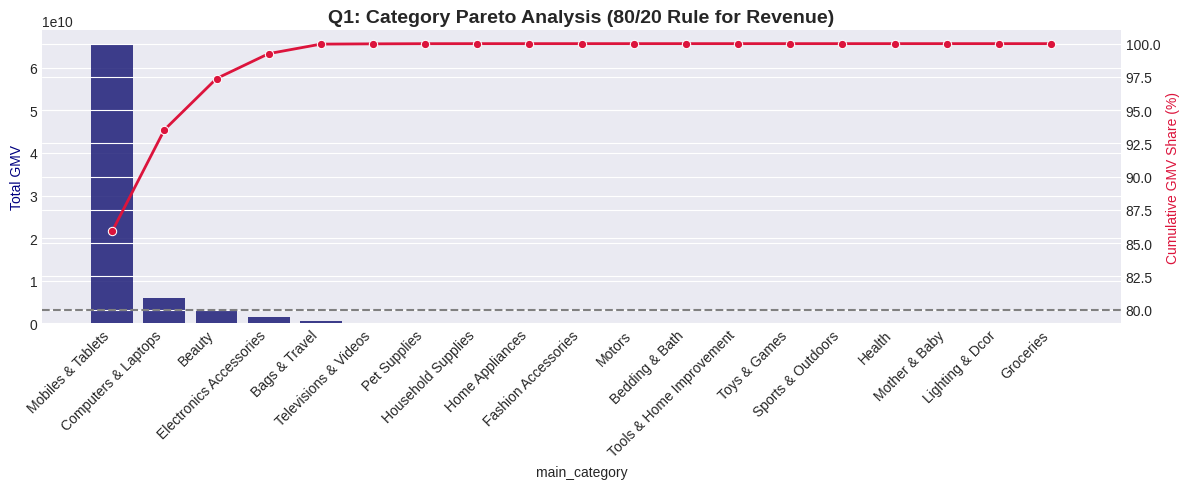

In [27]:

# Plot Pareto Combination Chart
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

sns.barplot(data=cat_summary, x='main_category', y='total_gmv', ax=ax1, color='navy', alpha=0.8)
sns.lineplot(data=cat_summary, x='main_category', y='cumulative_share_pct', ax=ax2, color='crimson', marker='o', linewidth=2)

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylabel('Total GMV', color='navy')
ax2.set_ylabel('Cumulative GMV Share (%)', color='crimson')
ax2.axhline(80, color='gray', linestyle='--', label='80% Pareto Cutoff')

plt.title('Q1: Category Pareto Analysis (80/20 Rule for Revenue)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Pareto Analysis Summary
The Pareto analysis reveals an extreme revenue concentration within Lazada's product catalog. A single dominant category, "Mobiles & Tablets", single-handedly accounts for over 86% of the total Gross Merchandise Value (GMV) generated across the platform. The top 3 categories combined (Mobiles & Tablets, Computers & Laptops, and Beauty) generate over 97% of total platform revenue, leaving the remaining 15+ categories with a long-tail contribution of less than 3%.

1. Key Business Insights & Strategic Recommendations
Class A / Core Revenue Drivers (Inventory & Co-Marketing Allocation):

    Insight: High-ticket electronic categories (Mobiles & Tablets and Computers & Laptops) represent the core financial backbone of the platform due to high Average Order Value (AOV).

    Action: Lazada must prioritize its warehouse space, priority fulfillment services, and top-tier co-marketing funds (e.g., mega-sale campaign banners) for top sellers in Mobiles & Tablets and Computers & Laptops to defend platform revenue.

2. Class B & C / Long-Tail Categories (Traffic & Repeat Purchase Drivers):

    Insight: Categories like Beauty, Electronics Accessories, Bags & Travel, and FMCG contribute marginally to GMV, but they typically drive high order frequency and user engagement.

    Action: Rather than tying up working capital by overstocking long-tail inventory, Lazada should leverage cross-selling and product bundling strategies (e.g., offering a discounted phone case or screen protector from Electronics Accessories when purchasing a phone from Mobiles & Tablets).

3. Platform Risk Mitigation:

    Insight: Relying on one category for >86% of revenue leaves the business vulnerable to industry shocks, supply chain delays, or shifts in consumer tech spending.

    Action: Gradually build growth campaigns around Class B categories (Computers & Laptops and Beauty) to diversify the platform's revenue streams without compromising current core sales.

In [28]:
# Discount effectiveness & Price Tiers
# Aggregating sales and discounts metrics across price tiers

tier_summary = df_clean.groupby('price_tier').agg(
    avg_discount_pct = ('discount_pct', 'mean'),
    avg_units_sold = ('number_sold', 'mean'),
    total_gmv = ('gmv','sum'),
    product_counts = ('sku', 'count')
).reset_index()

print("\n--- Discount performance across price tiers")
print(tier_summary)


--- Discount performance across price tiers
           price_tier  avg_discount_pct  avg_units_sold     total_gmv  \
0     1. Low (<=100k)         33.822362     1646.766298  2.314895e+09   
1  2. Mid (100k-500k)         13.721538      237.967033  4.485649e+09   
2   3. High (500k-1M)         20.339697       36.090909  1.053995e+09   
3    4. Premium (>1M)         10.730164       66.786885  6.848416e+10   

   product_counts  
0             813  
1              91  
2              33  
3              61  


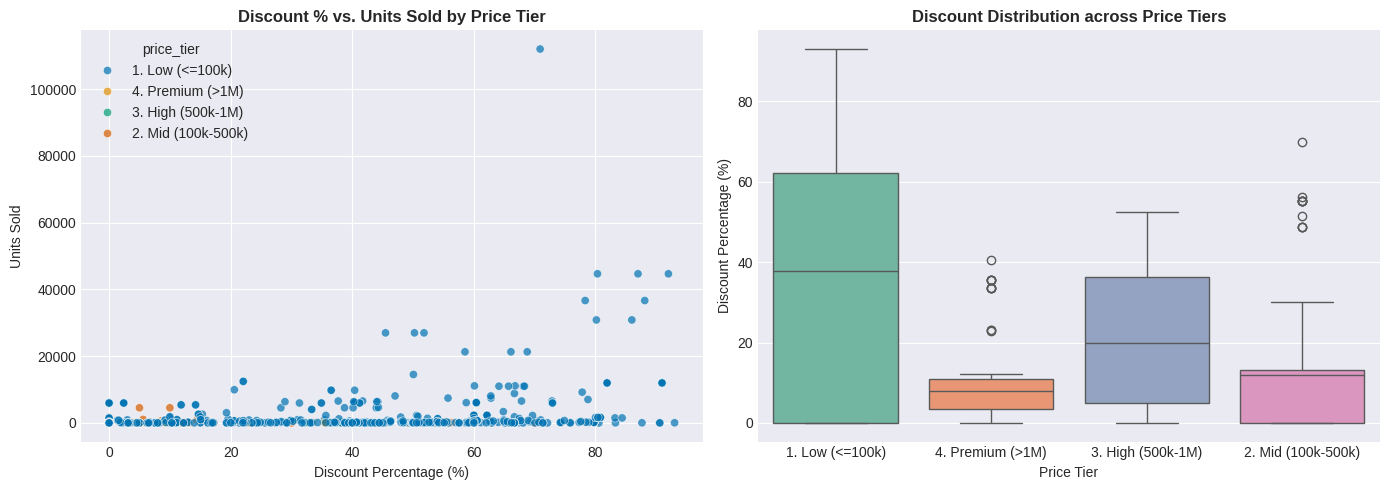

In [29]:
# Plot for discount distributions vs sales volume
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df_clean, x='discount_pct', y='number_sold', hue='price_tier', alpha=0.7, ax=axes[0])
axes[0].set_title('Discount % vs. Units Sold by Price Tier', fontweight='bold')
axes[0].set_xlabel('Discount Percentage (%)')
axes[0].set_ylabel('Units Sold')

sns.boxplot(data=df_clean, x='price_tier', y='discount_pct', ax=axes[1], palette='Set2')
axes[1].set_title('Discount Distribution across Price Tiers', fontweight='bold')
axes[1].set_xlabel('Price Tier')
axes[1].set_ylabel('Discount Percentage (%)')

plt.tight_layout()
plt.show()

### Discount Effectiveness & Price Tiers Summary

The relationship between discount percentage and sales volume varies drastically across different price tiers. High sales volume (>20k units) is heavily concentrated in the "Low Price Tier (<=100k)", where aggressive discounts (>50%) successfully act as a primary demand driver. Conversely, higher price tiers (Mid, High, and Premium) show low price elasticity, meaning discounts alone do not guarantee a proportional surge in units sold and primarily risk eroding profit margins.

- Price Elasticity & Volume Drivers (Low Tier <=100k):
    - Insight: Products priced under Rp 100k exhibit high price elasticity. Sellers heavily rely on deep discounts (median ~38%, going up to >80%) to push high volume sales, driving mass-market platform engagement.
    - Action: Maintain aggressive discounting strategies and flash sales for Low Tier products to drive platform user acquisition and high-frequency transactions.

- Margin Protection & Premium Positioning (Premium >1M & Mid Tier)::
  - Insight: Premium (>1M) and Mid Tier (100k-500k) products maintain low median discounts (<12%). High discounts on premium goods rarely produce volume spikes comparable to low-tier items.
  - Action: Avoid deep price cuts (>20%) on Premium products. Instead of direct price slashing, utilize value-add promotions (e.g., free shipping, bundled accessories, or installment plans) to incentivize sales without devaluing the brand or sacrificing profit margins.
- Optimal Discount Range Framework:
  - Low Tier (<=100k): 40% – 60% discount range is optimal to trigger volume surges.

  - Mid Tier (100k-500k): 10% – 20% discount threshold to boost conversions without margin loss.

  - High / Premium Tier (>500k): 5% – 15% max discount. Focus marketing budget on seller credibility, warranty, and authentic product badges (LazMall) rather than direct price cuts.

In [30]:
# Lazmall & Super Seller Program Impact
seller_program_summary = df_clean.groupby(['lazmall','is_super_seller']).agg(
    total_gmv=('gmv', 'sum'),
    avg_gmv_per_products=('gmv', 'mean'),
    avg_units_sold=('number_sold','mean'),
    avg_ratings=('rating','mean'),
    avg_seller_ratings=('seller_ratings','mean'),
    seller_count=('sku', 'count')
).reset_index()

print("\n--- Program Performance Comparison ---")
print(seller_program_summary)


--- Program Performance Comparison ---
   lazmall  is_super_seller     total_gmv  avg_gmv_per_products  \
0    False            False  3.258030e+09          4.798276e+06   
1     True             True  7.308067e+10          2.290930e+08   

   avg_units_sold  avg_ratings  avg_seller_ratings  seller_count  
0      834.512518     3.391163            0.963152           679  
1     2505.037618     3.536364            0.969091           319  


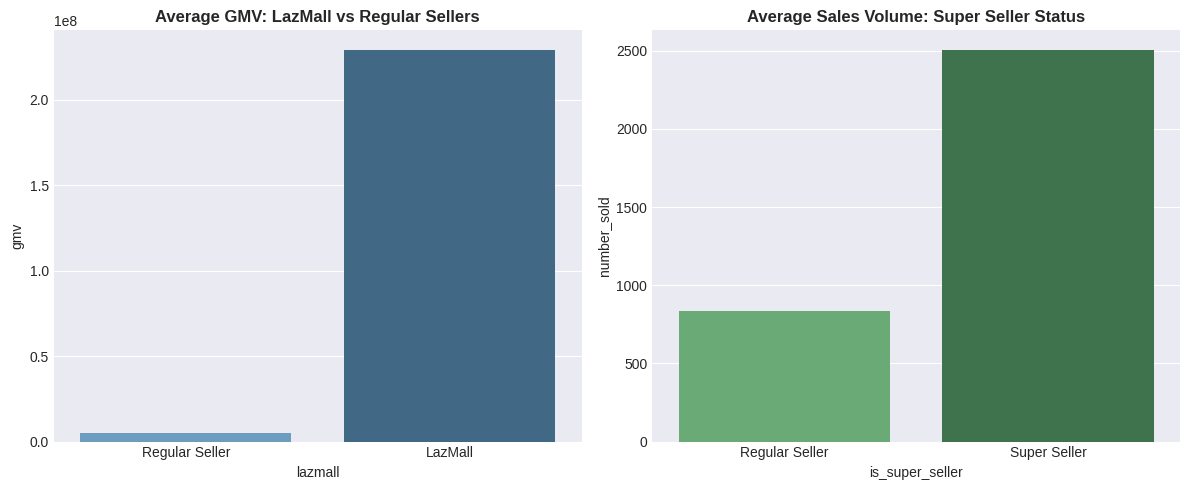

In [31]:
# Plot LazMall vs Non LazMall Lift Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df_clean, x='lazmall', y='gmv', ax=axes[0], ci=None, palette='Blues_d')
axes[0].set_title('Average GMV: LazMall vs Regular Sellers', fontweight='bold')
axes[0].set_xticklabels(['Regular Seller', 'LazMall'])

sns.barplot(data=df_clean, x='is_super_seller', y='number_sold', ax=axes[1], ci=None, palette='Greens_d')
axes[1].set_title('Average Sales Volume: Super Seller Status', fontweight='bold')
axes[1].set_xticklabels(['Regular Seller', 'Super Seller'])

plt.tight_layout()
plt.show()

### LazMall and Super Seller Efectiveness
1. Average GMV: LazMall vs. Regular Sellers
  - Data Observations:
    - Regular Seller: Average Gross Merchandise Value (GMV) is very low, hovering under $< 0.1 \times 10^8$ (below IDR 5–10 million).
    - LazMall: Average GMV surges dramatically to nearly $2.3 \times 10^8$ (approximately IDR 230 millions.
  - Analysis & Interpretation:
    The substantial gap in GMV is driven by key e-commerce ecosystem dynamics:
    - Consumer Trust Factor: The LazMall badge guarantees 100% authentic products and reliable return policies, significantly reducing the buyer's perceived risk during high-value transactions.
    - Basket Size & Price Point: LazMall is predominantly composed of official brand stores and authorized distributors selling higher-priced, high-ticket items (e.g., consumer electronics, branded fashion, licensed cosmetics). This naturally inflates the Average Order Value (AOV) compared to standard sellers
    - Algorithmic & Marketing Boost: E-commerce platforms systematically prioritize LazMall merchants in search placement, homepage feature slots, and mega-campaigns (e.g., double-date mega sales).

2. Average Sales Volume: Super Seller Status
  - Data Observations:
    - Regular Seller: Average units sold (number_sold) ranges around ~830–850 units.
    - Super Seller: Average units sold leaps to ~2,500 units (a ~200% increase or 3x multiplier).

  - Analysis & Interpretation:
    Unlike LazMall which centers on official brand partnerships—the Super Seller status is awarded to high-performing marketplace merchants who meet strict operational metrics (e.g., fast response times, high store ratings, and low cancellation rates).
    - Operational Efficiency: Super Sellers achieve higher conversion rates because positive reviews and high ratings serve as strong social proof, signaling reliability to prospective buyers.
    - Volume Acceleration: The 3x increase in sales volume demonstrates that the "Super Seller" badge functions as an effective nudging mechanism, prompting buyers to choose badged stores over unbadged alternatives when buying similar products.

3. Strategic Takeaways
    
    Premiumization vs. High-Volume Strategy:

    - To maximize revenue per transaction (GMV), transitioning to an Official Store / LazMall model is the primary revenue driver.

    - To maximize inventory turnover rates, obtaining Super Seller status is highly effective for scaling unit volume.

    - Selection Bias & Platform Synergy: While there is an inherent selection bias (merchants qualifying for LazMall/Super Seller often possess higher initial capital or market traction), the platform actively amplifies this growth through superior visibility and consumer protection features.

In [32]:
# Factors influencing product sales
numeric_features = [
    'number_sold', 'gmv','final_price','discount_pct','rating','reviews',
    'seller_ratings','seller_ship_on_time','seller_chat_response','color_variant_count'
]

corr_matrix = df_clean[numeric_features].corr()

In [33]:
print("\n--- Feature correlations with sales volume (number sold)")
print(corr_matrix[['number_sold']].sort_values(by='number_sold', ascending=False))


--- Feature correlations with sales volume (number sold)
                      number_sold
number_sold              1.000000
reviews                  0.936032
discount_pct             0.250518
rating                   0.159487
seller_ship_on_time      0.094958
seller_ratings           0.086105
color_variant_count     -0.004558
seller_chat_response    -0.009539
gmv                     -0.022894
final_price             -0.049102


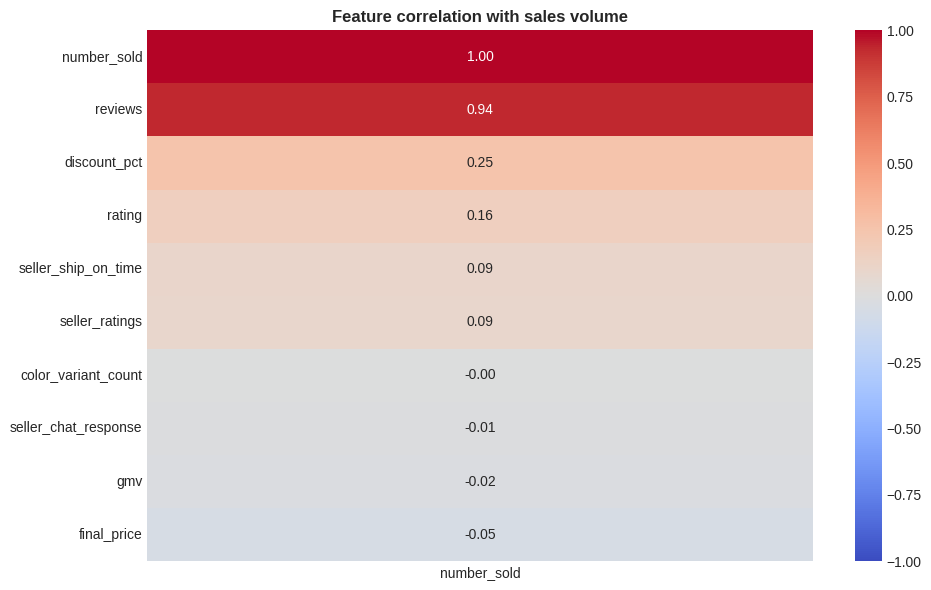

In [34]:
# Heatmap visualization
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix[['number_sold']].sort_values(by='number_sold', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Feature correlation with sales volume', fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation heatmap of sales volume & available features
The correlation heatmap reveals that sales volume (number_sold) is overwhelmingly driven by social proof, showing a near-perfect positive correlation with total reviews (0.94). Meanwhile, promotional incentives like discount_pct (0.25) and baseline trust metrics like product rating (0.16) have only a weak-to-moderate impact on driving quantity. Interestingly, seller operational metrics (seller_ship_on_time, seller_chat_response) and product prices (final_price) show virtually no direct linear relationship with unit sales volume, indicating that consumers prioritize heavy social validation over minor operational or price differences when choosing what to buy.

In [35]:
# Preparation for machine learning & Clustering
print(" Target Distribution Check")
print(f"Skewness of number_sold: {df_clean['number_sold'].skew():.2f}")

 Target Distribution Check
Skewness of number_sold: 11.27


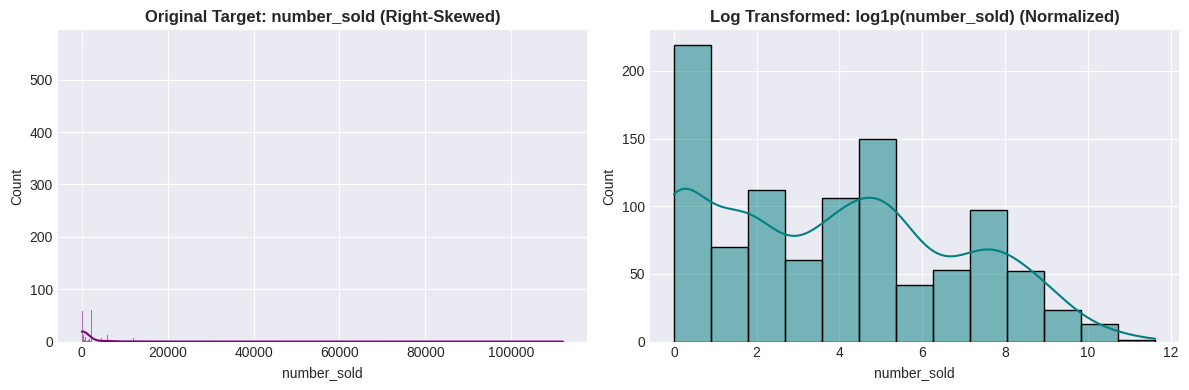

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_clean['number_sold'], kde=True, ax=axes[0], color='purple')
axes[0].set_title('Original Target: number_sold (Right-Skewed)', fontweight='bold')

sns.histplot(np.log1p(df_clean['number_sold']), kde=True, ax=axes[1], color='teal')
axes[1].set_title('Log Transformed: log1p(number_sold) (Normalized)', fontweight='bold')

plt.tight_layout()
plt.show()

# Strategic Business Recommendations Based on E-Commerce Data Analysis

## Executive Summary
Based on the Exploratory Data Analysis (EDA) of sales performance, seller ecosystem classification (*seller tier*), and consumer behavior patterns within the e-commerce platform, three primary strategic pillars have been established. These recommendations focus on optimizing social proof, establishing dual-track seller growth pathways, and reallocating operational resources efficiently.

---

## 1. Capitalize on the "Social Proof Flywheel" (Feedback Loop Analysis)

### Background & Methodological Caveat
* **High Endogenous Correlation:** Correlation analysis shows a near-perfect positive association (**0.94**) between product reviews (`reviews`) and sales volume (`number_sold`).
* **Reverse Causality & Simultaneity:** It is crucial to note that correlation does not equal causation. Higher sales naturally generate more reviews (Reverse Causality), which in turn build social proof that drives subsequent purchases. Rather than a one-way driver, these two variables form a **Virtuous Cycle (Flywheel Effect)**.
* **Secondary Drivers:** Price discounts (`discount_pct`) demonstrate a weaker correlation (**0.25**), indicating that direct price cuts alone are less effective at sustaining volume compared to accumulated social validation.

### Actionable Recommendations
1. **Accelerate the Review Flywheel:**
   * Instead of relying solely on steep direct price discounts, reallocate promotional budgets toward **Post-Purchase Review Incentive Programs** (e.g., store coins, loyalty points, or cashback for verified photo/video reviews). This speeds up the cold-start phase for new products to build initial momentum.
2. **Review-Driven Conversion Funnel:**
   * Prominently display high-quality, verified customer reviews on product detail pages to reduce decision friction for prospective buyers entering the flywheel.

---

## 2. Implement a Dual-Track Growth Strategy for Sellers

### Background & Key Findings
* **LazMall Pathway:** Merchants with LazMall status achieve an average Gross Merchandise Value (GMV) **~45x higher** (~IDR 230M) compared to Regular Sellers (< IDR 10M).
* **Super Seller Pathway:** Merchants with Super Seller status boost their average sales volume (`number_sold`) by **~3x** (2,500 units) compared to Regular Sellers (830 units).

### Actionable Recommendations
1. **High-Value Pathway (LazMall) – GMV Optimization:**
   * Target official brands, authorized distributors, and merchants selling high-ticket items.
   * **Focus:** Leverage brand trust and official consumer guarantees to maximize Average Order Value (AOV).
2. **High-Volume Pathway (Super Seller) – Volume Optimization:**
   * Target Regular Sellers operating in fast-moving consumer goods (FMCG) or daily-use categories.
   * **Focus:** Meet core platform operational metrics to earn the Super Seller badge, thereby accelerating conversion rates and inventory turnover.

---

## 3. Restructure Operational KPIs (Hygiene vs. Growth Factors)

### Background & Key Findings
* Operational indicators such as shipping speed (`seller_ship_on_time` = 0.09) and chat response rate (`seller_chat_response` = -0.01) show negligible to near-zero direct linear correlation with sales volume.

### Actionable Recommendations
1. **Redefine Operational Performance as a *Hygiene Factor*:**
   * Fast chat responses and timely fulfillment should be treated as baseline operational standards required to avoid negative reviews, rather than primary revenue drivers.
2. **Optimize Resource Allocation:**
   * Advise sellers against over-investing capital solely to push chat response metrics from 95% to 99% if their listings lack sufficient social proof (`reviews`). Resources are far better allocated toward review acquisition and store branding.

---

## Strategic Summary Matrix

| Strategic Pillar | Key Data Finding & Nuance | Core Recommendation | Expected Business Impact |
| :--- | :--- | :--- | :--- |
| **Social Proof Flywheel** | High correlation (`reviews` = 0.94) driven by a **virtuous cycle / reverse causality** | Shift price-discount budgets toward incentivized review acquisition | Accelerates product cold-starts & strengthens conversion momentum |
| **Dual-Track Growth** | LazMall (GMV ~45x) & Super Seller (Volume ~3x) | Classify seller growth pathways based on product tiers (High-Value vs. High-Volume) | Maximizes GMV for official stores & speeds up inventory turnover for regular sellers |
| **KPI Restructuring** | Operational metrics correlation < 0.10 | Reframe operational metrics as foundational hygiene factors | Streamlines operational costs & optimizes ROI |

 # Sales Prediction Modeling
 ---

## Feature Engineering

In [37]:
# feature engineering
def create_features(df):
  data = df.copy()

  if 'number_sold' in data.columns:
    data['target_log'] = np.log1p(data['number_sold'])

  # Feature 1 : Social proof per price (review intensity)
  data['reviews_per_price']  = data['reviews'] / (data['final_price'] + 1)

  # Feature 2: Combined seller tier status
  def assign_seller_tier(row):
    if row.get('lazmall', 0) == 1 and row.get('is_super_seller', 0) ==1:
      return 'LazMall_Super'
    elif row.get('lazmall', 0) ==1:
      return 'LaMall_only'
    elif row.get('is_super_seller', 0) ==1:
      return 'Super_only'
    else:
      return 'regular'

  data['seller_tier'] = data.apply(assign_seller_tier, axis=1)

  # Feature 3 operational composite score
  data['operational_score'] = (data['seller_ship_on_time'] + data['seller_chat_response']) / 2.0

  return data

In [38]:
df_processed = create_features(df_clean)

## Data Splitting & Preparation
---

In [39]:
X  = df_processed[[
    'reviews',
    'discount_pct',
    'rating',
    'final_price',
    'reviews_per_price',
    'operational_score',
    'seller_tier',
    'color_variant_count'
]]

y_log = df_processed['target_log']

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

## Preprocessing Pipeline
---

In [40]:
num_cols = ['reviews', 'discount_pct', 'rating', 'final_price', 'reviews_per_price', 'operational_score','color_variant_count']

cat_cols = ['seller_tier']

preprocesssor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

## Model Evaluation Helper
---

In [41]:
def evaluate_model(model, X_train, y_train_log, X_test, y_test_log, name="model"):
  model.fit(X_train, y_train_log)

  y_pred_log = model.predict(X_test)

  # INversing predictions and actual values back to original scale
  y_test_orig = np.expm1(y_test_log)
  y_pred_orig = np.expm1(y_pred_log)

  # Calculate metrics in original scale
  rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
  mae = mean_absolute_error(y_test_orig, y_pred_orig)
  r2 = r2_score(y_test_orig, y_pred_orig)

  print(f"{name} performance (original scale)")
  print(f"RMSE : {rmse:.2f}")
  print(f"MAE : {mae:.2f}")
  print(f"R2 : {r2:.2f}")
  return model

## Model Training and Comparison
---

In [42]:
# Model 1: Ridge Regression
ridge_pipeline = Pipeline([
    ('preprocesssor', preprocesssor),
    ('regressor', Ridge(alpha=0.1))
])
ridge_model = evaluate_model(ridge_pipeline, X_train, y_train_log, X_test, y_test_log, "Ridge Regression")

# Model 2: XGBoost regressor
xgb_pipeline = Pipeline([
    ('preprocesssor', preprocesssor),
    ('regressor', xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ))
])
xgb_model = evaluate_model(xgb_pipeline, X_train, y_train_log, X_test, y_test_log, "XGBoost Regressor")

# Model 3: LightGBM Regressor
lgb_pipeline = Pipeline([
    ('preprocesssor', preprocesssor),
    ('regressor', lgb.LGBMRegressor(
        n_estimators=100,
        learning_rate=0.05,
        random_state=42,
        num_leaves=20,
        min_child_samples=30,
        max_depth=5
    ))
])
lgb_model = evaluate_model(lgb_pipeline, X_train, y_train_log, X_test, y_test_log, "LightGBM Regressor")

Ridge Regression performance (original scale)
RMSE : 1824.18
MAE : 707.09
R2 : 0.75
XGBoost Regressor performance (original scale)
RMSE : 1108.23
MAE : 143.78
R2 : 0.91
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 731
[LightGBM] [Info] Number of data points in the train set: 798, number of used features: 8
[LightGBM] [Info] Start training from score 3.866172
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

In [43]:
# Best Model Saving
joblib.dump(xgb_pipeline, "xgb_sales_pipeline_full.joblib")
print("✅ Entire pipeline successfully saved as 'xgb_sales_pipeline_full.joblib'")

✅ Entire pipeline successfully saved as 'xgb_sales_pipeline_full.joblib'


## Predictive sales model summary
To support Lazada’s inventory planning and demand forecasting, an advanced Machine Learning pipeline was built to predict product sales volume (number_sold). Due to severe right-skewness in transaction data, a logarithmic transformation ($\log(1+x)$) was applied alongside targeted feature engineering. Among the evaluated algorithms, the XGBoost Regressor achieved outstanding performance, explaining 91% of sales variance ($R^2 = 0.91$) with a low Mean Absolute Error of ~144 units. This high-precision model enables supply chain teams to optimize safety stock levels, prevent costly stockouts, and reduce overstock risks prior to major promotional campaigns.

# Product Segmentation Modelling
---

In [44]:
SEED = 42
np.random.seed(SEED)

## Feature Preparation & Preprocessing

In [45]:
cluster_features = ['number_sold', 'gmv', 'final_price', 'reviews']

if 'gmv' not in df_clean.columns:
    df_clean['gmv'] = df_clean['number_sold'] * df_clean['final_price']

X_log = np.log1p(df_clean[cluster_features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

## Elbow method & Silhouette Analysis
---

In [46]:
inertia = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

  score = silhouette_score(X_scaled, kmeans.labels_)
  silhouette_scores.append(score)

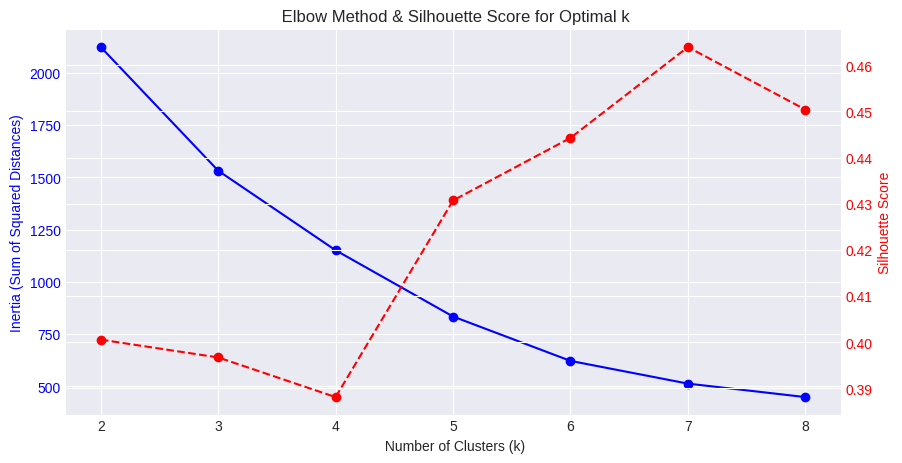

In [47]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(k_range, inertia, 'bo-', label='Inertia (SSE)')
ax1.set_xlabel(' Number of Clusters (k)')
ax1.set_ylabel('Inertia (Sum of Squared Distances)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_title(' Elbow Method & Silhouette Score for Optimal k')

# Plot Silhouette Score on secondary axis
ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, 'ro--', label='Silhouette Socre')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.grid(True)
plt.show()

Evaluating both the Elbow Method (Inertia) and Silhouette Analysis indicates $k = 5$ as the optimal cluster count. At $k = 5$, the Inertia curve displays a clear elbow bend, signaling diminishing returns for additional clusters, while the Silhouette Score undergoes a sharp upward inflection to 0.43. While $k = 7$ offers the peak Silhouette Score (0.465), $k = 5$ provides a superior trade-off between statistical cluster separation and actionable business interpretability.

## Model Fitting
---

In [48]:
# Final K-Means model set to optimal_k based on the elbow method
OPTIMAL_K = 5
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=SEED, n_init=10)
df_clean['raw_cluster'] = kmeans.fit_predict(X_scaled)

In [49]:
cluster_means = df_clean.groupby('raw_cluster')['gmv'].mean().sort_values()

sorted_cluster_mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_means.index)}

df_clean['cluster_id'] = df_clean['raw_cluster'].map(sorted_cluster_mapping)

segment_names = {
    0: 'Tier 5 (Low Potential)',
    1: 'Tier 4 (Slow Movers)',
    2: 'Tier 3 (Mid-Range)',
    3: 'Tier 2 (High Potential)',
    4: 'Tier 1 (Star Products)'
}

df_clean['Product_Segment'] = df_clean['cluster_id'].map(segment_names)
df_clean.drop(columns=['raw_cluster'], inplace=True)

## Model Saving
---

In [50]:
# Saving the model
segmentation_bundle = {
    'model': kmeans,
    'scaler': scaler,
    'features': cluster_features,
    'cluster_mapping': sorted_cluster_mapping,
    'segment_names': segment_names
}

# Save the bundle to disk
joblib.dump(segmentation_bundle, 'kmeans_lazada_segmentation.joblib')
print("Model bundle successfully saved to 'kmeans_lazada_segmentation.joblib'")

Model bundle successfully saved to 'kmeans_lazada_segmentation.joblib'


## Segmentation Model Summary and Insight
---

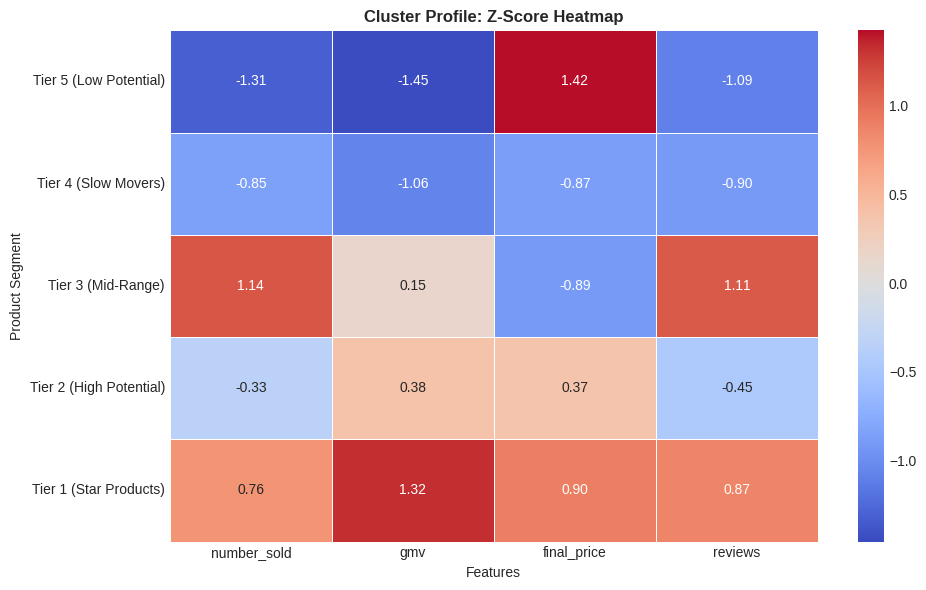

In [51]:
# Create a DataFrame from the scaled data to calculate Z-scores
df_scaled = pd.DataFrame(X_scaled, columns=cluster_features)
df_scaled['Product_Segment'] = df_clean['Product_Segment'].values

# Calculate the mean Z-score for each feature within each segment
cluster_z_scores = df_scaled.groupby('Product_Segment').mean()

# Reorder the index so the heatmap reads logically from Tier 5 to Tier 1
ordered_index = [
    'Tier 5 (Low Potential)',
    'Tier 4 (Slow Movers)',
    'Tier 3 (Mid-Range)',
    'Tier 2 (High Potential)',
    'Tier 1 (Star Products)'
]
cluster_z_scores = cluster_z_scores.reindex(ordered_index)

# Plot the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_z_scores,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    center=0 # 0 represents the dataset average
)
plt.title("Cluster Profile: Z-Score Heatmap", fontweight='bold')
plt.xlabel("Features")
plt.ylabel("Product Segment")
plt.tight_layout()
plt.show()

Variance explained by PC1: 63.89%
Variance explained by PC2: 30.36%


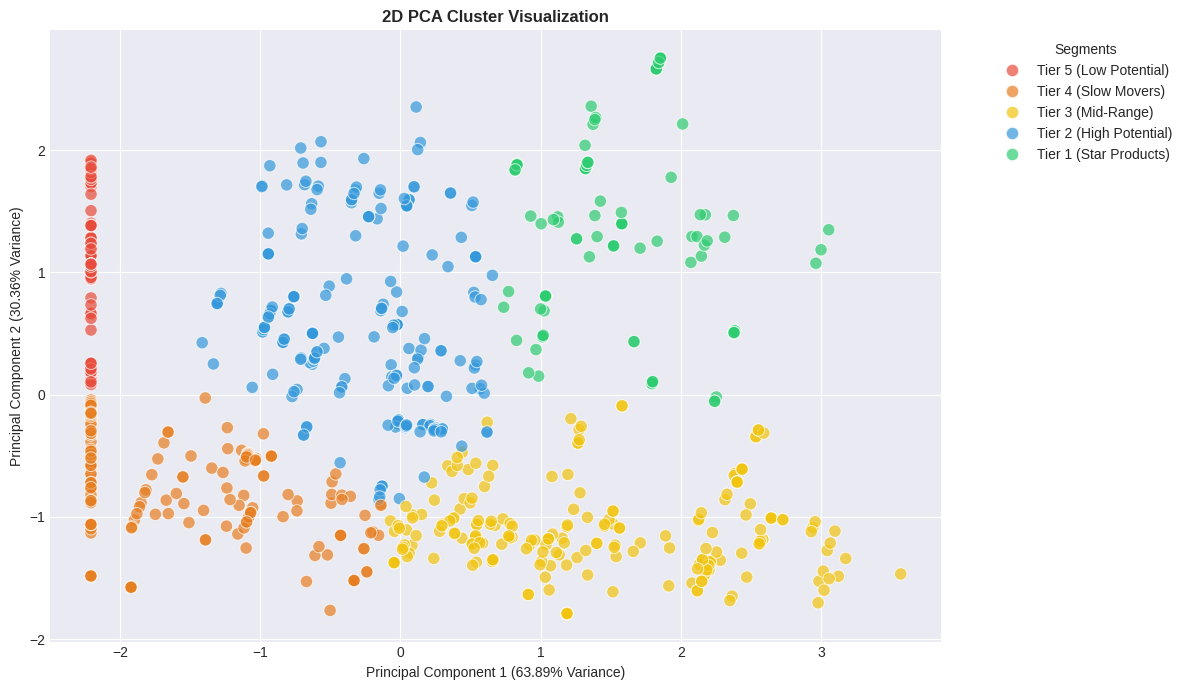

In [52]:
# Initialize PCA to reduce data to 2 dimensions
pca = PCA(n_components=2, random_state=SEED)
pca_components = pca.fit_transform(X_scaled)

# Add the principal components to a plotting dataframe
df_pca = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
df_pca['Product_Segment'] = df_clean['Product_Segment'].values

# Calculate explained variance to understand how much information was retained
explained_variance = pca.explained_variance_ratio_ * 100
print(f"Variance explained by PC1: {explained_variance[0]:.2f}%")
print(f"Variance explained by PC2: {explained_variance[1]:.2f}%")

# Plot the PCA Scatter
plt.figure(figsize=(12, 7))

# Define a distinct, fixed color palette for the 5 tiers
pca_palette = {
    'Tier 5 (Low Potential)': '#e74c3c',   # Red
    'Tier 4 (Slow Movers)': '#e67e22',     # Orange
    'Tier 3 (Mid-Range)': '#f1c40f',       # Yellow
    'Tier 2 (High Potential)': '#3498db',  # Blue
    'Tier 1 (Star Products)': '#2ecc71'    # Green
}

sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='Product_Segment',
    palette=pca_palette,
    alpha=0.7,
    s=80,
    hue_order=ordered_index # Keeps the legend in a logical order
)

plt.title("2D PCA Cluster Visualization", fontweight='bold')
plt.xlabel(f"Principal Component 1 ({explained_variance[0]:.2f}% Variance)")
plt.ylabel(f"Principal Component 2 ({explained_variance[1]:.2f}% Variance)")
plt.legend(title="Segments", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The Z-Score heatmap provides a clear operational profile for each segment, while the PCA plot confirms that these groups are mathematically distinct, meaning marketing and inventory strategies can be applied with high precision.

1. Tier 1: Star Products (The Cash Cows)

  - Profile: Above average across all metrics. High GMV (1.32), solid volume (0.76), high engagement (0.87), and premium pricing (0.90).

  - Insight: These are the platform's heavyweights. Customers are highly engaged (writing reviews) and willing to pay a premium, driving massive revenue.

2. Tier 2: High Potential (The Margin Makers)

  - Profile: Above average GMV (0.38) driven entirely by higher pricing (0.37). Volume (-0.33) and reviews (-0.45) are lagging.

  - Insight: These items have excellent profit margins but struggle with conversion velocity. If the sales volume can be marginally improved, they will generate massive GMV.

3. Tier 3: Mid-Range (The Traffic Drivers)

  - Profile: The highest sales volume (1.14) and review engagement (1.11) on the platform, but the lowest price points (-0.89).

  - Insight: These are mass-market, "basket-filler" items. They keep consumers opening the Lazada app and interacting with the platform, even if the individual profit per item is small.

4. Tier 4: Slow Movers (The Noise)

  - Profile: Cheap items (-0.87) that generate zero traction. Volume (-0.85), reviews (-0.90), and GMV (-1.06) are all severely depressed.

  - Insight: This is low-value clutter. These products fail to capture consumer interest despite being highly affordable.

5. Tier 5: Low Potential (The Dead Weight)

  - Profile: The most expensive items on the platform (1.42), but they have the absolute worst sales volume (-1.31) and lowest GMV (-1.45).

  - Insight: These products are a massive liability. They are priced out of the market, generating no revenue, and likely incurring high holding costs if stored in local fulfillment centers.

To optimize the supply chain and maximize platform profitability, specific interventions should be applied to each segment.

1. Revenue Optimization Tactics
    - Tier 1 (Star Products) - VIP Treatment: Secure the supply chain for these SKUs. Ensure these sellers are onboarded to "Fulfilled by Lazada" (FBL) to guarantee fast shipping and prevent stockouts. Allocate prime homepage real estate and LazMall banners to these items, as they have proven conversion rates.

    - Tier 3 (Mid-Range) - Boost Average Order Value (AOV): Since these items drive massive volume but low GMV, implement aggressive "Buy 2 Get 1 Free" or "Minimum Spend for Free Shipping" rules. Use algorithm recommendations to cross-sell these high-volume cheap items alongside Tier 1 and Tier 2 products.

    - Tier 2 (High Potential) - Conversion Nudging: Break the volume bottleneck by deploying targeted flash sales, offering flexible installment plans (LazPayLater), or subsidizing discount vouchers. A slight bump in volume here will yield a massive spike in total platform GMV.

2. Cost-Cutting & Efficiency Tactics
    - Tier 5 (Low Potential) - Stop the Bleed: Immediately revoke any subsidized marketing, free shipping, or platform visibility for these SKUs. If Lazada holds this inventory, return it to the seller or force a massive liquidation sale to free up expensive warehouse capacity.

    - Tier 4 (Slow Movers) - Algorithm Demotion: Deprioritize these items in the search algorithm. They consume server processing power and crowd the user interface without generating revenue. Advise sellers to either drop prices to clearance levels or delist the SKUs entirely to improve their overall store conversion rate.

## Final Summary and Insight for Each Business Question

---

### 1. Which categories and products generate the highest GMV (Gross Merchandise Value), and how should Lazada allocate its inventory and marketing resources to maximize revenue?

**Summary:** Revenue is highly concentrated, with 'Mobiles & Tablets' accounting for over 86% of total GMV. The top 3 categories (Mobiles & Tablets, Computers & Laptops, Beauty) generate over 97% of revenue.

**Recommendations:**
*   **Prioritize Core Revenue Drivers:** Allocate prime resources (warehouse, fulfillment, marketing) to 'Mobiles & Tablets' and 'Computers & Laptops'.
*   **Diversify Revenue:** Strategically grow Class B categories (e.g., 'Beauty') to reduce dependence on 'Mobiles & Tablets'.
*   **Leverage Long-Tail Categories:** Use categories like 'Electronics Accessories' and 'Bags & Travel' for cross-selling and bundling rather than heavy inventory investment.
---

### 2. How effective are discounts in driving sales, and what is the optimal discount range for each product category to maximize sales without sacrificing profit margins?

**Summary:** Discount effectiveness varies by price tier. Low-tier products (<100k IDR) show high price elasticity, while higher tiers (Mid, High, Premium) are less responsive to deep discounts.

**Recommendations:**
*   **Low Tier (<=100k IDR):** Maintain aggressive discounts (40%–60%) for volume and user acquisition.
*   **Mid Tier (100k-500k IDR):** Use moderate discounts (10%–20%) to boost conversions without significant margin loss.
*   **High/Premium Tier (>500k IDR):** Limit discounts (max 5%–15%). Focus on value-added promotions (free shipping, bundles) and highlighting brand trust (LazMall) to preserve margins and brand perception.
---

### 3. How do LazMall and Super Seller programs impact seller performance (GMV, sales volume, and ratings), and is the platform's investment in these programs justified?

**Summary:** Both programs significantly boost seller performance, justifying platform investment.

*   **LazMall:** Drives ~45x higher average GMV compared to regular sellers, due to consumer trust, higher average order values from branded products, and algorithmic prioritization.
*   **Super Seller:** Increases average sales volume by ~3x (from ~830 to ~2,500 units) due to increased buyer confidence from meeting operational excellence metrics.

**Recommendations:**
*   **Dual-Track Growth:** Promote LazMall for high-value/branded products (GMV optimization) and Super Seller status for high-volume products (inventory turnover).
*   **Amplify Growth:** Continue to leverage platform features (visibility, consumer protection) that amplify the growth of these badged sellers.
---

### 4. What factors (rating, reviews, price, seller reputation, promotions) most significantly influence product sales, and what should be Lazada's priority for improvement?

**Summary:** Sales volume (`number_sold`) is overwhelmingly influenced by social proof, with a strong positive correlation to `reviews` (0.94). `discount_pct` (0.25) and `rating` (0.16) have weaker impacts. Operational metrics (`seller_ship_on_time`, `seller_chat_response`) show negligible direct correlation.

**Recommendations:**
*   **Prioritize Social Proof:** Shift promotional budgets towards incentivizing post-purchase reviews to accelerate the 'review flywheel' for products.
*   **Review-Driven Funnel:** Highlight high-quality customer reviews prominently to reduce buying friction.
*   **Operational KPIs as Hygiene Factors:** Treat seller operational metrics as baseline requirements to prevent negative experiences, rather than primary sales drivers. Resources are better spent on review acquisition and branding.
---

### 5. Can we build a machine learning model to predict product sales volume (number_sold) based on product attributes, and use it for inventory planning?

**Summary:** Yes, an XGBoost Regressor model was successfully built and achieved excellent performance with an R² of 0.91 and a low MAE of approximately 144 units after log-transforming the target variable (`number_sold`) due to its skewed distribution.

**Recommendations:**
*   **Inventory Optimization:** Utilize this high-precision model for optimizing safety stock levels, preventing stockouts, and reducing overstock risks for better inventory planning.
*   **Demand Forecasting:** The model can be integrated into demand forecasting processes, especially before major promotional campaigns.
---

### 6. How can we classify products into meaningful segments (e.g., high-potential, underperforming, premium) and use these segments to design targeted marketing and pricing strategies?

**Summary:** Products were successfully classified into 5 meaningful segments (Tier 1: Star Products to Tier 5: Low Potential) using K-Means clustering on key features (`number_sold`, `gmv`, `final_price`, `reviews`), after log transformation and scaling. The Elbow Method and Silhouette Analysis indicated an optimal `k=5` clusters, balancing statistical separation with business interpretability.

**Recommendations (Targeted Strategies per Segment):**
*   **Tier 1 (Star Products):** VIP treatment (secure supply chain, FBL, prime visibility) to maintain market leadership.
*   **Tier 2 (High Potential):** Conversion nudging (flash sales, installment plans, vouchers) to boost volume for high-margin products.
*   **Tier 3 (Mid-Range):** Boost AOV (Buy 2 Get 1, minimum spend free shipping, cross-sell with higher-tier products) to leverage high volume.
*   **Tier 4 (Slow Movers):** Algorithm demotion and advise sellers to clear inventory or delist to reduce platform clutter.
*   **Tier 5 (Low Potential):** Stop the bleed (revoke marketing, liquidate inventory) to free up resources from dead-weight products.
